<a href="https://colab.research.google.com/github/NaydelinAidee/Procesos-Estocasticos/blob/main/MATRIZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?

Resolver a detalle.


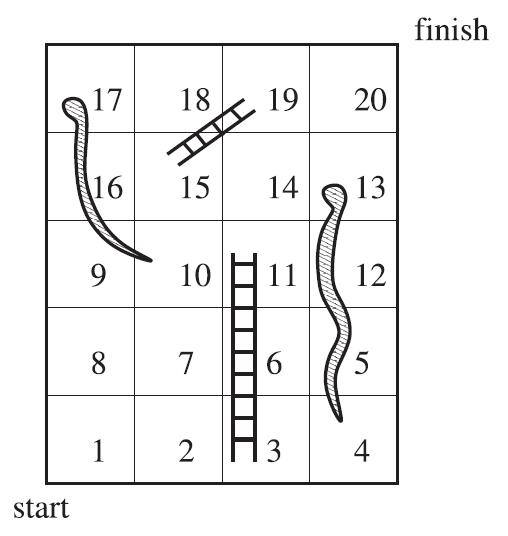
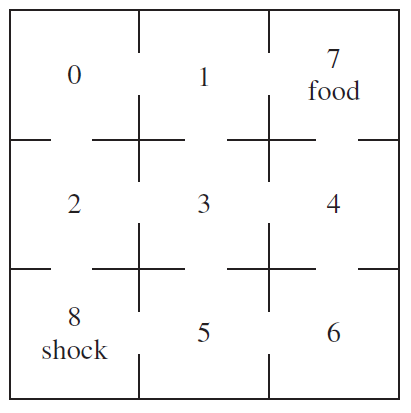

**Serpientes y Escaleras**
1. Análisis del Tablero y Reglas.

Casillas: El tablero tiene de la casilla 1 (inicio) hasta la 20 (meta). Asumimos que el jugador inicia en la casilla 1 y debe llegar exactamente o pasar la casilla 20 para terminar (absorción).

se juega con un dado estándar de 6 caras, con probabilidades iguales de 1/6 para avanzar de 1 a 6 casillas.

Efectos de las casillas :

* Escalera de 3 a 11: Si caes en 3, subes a 11.

* Escalera de 15 a 19: Si caes en 15, subes a 19.

* Serpiente de 17 a 9: Si caes en 17, bajas a 9.

* Serpiente de 13 a 4: Si caes en 13, bajas a 4.

Las casillas base de escaleras y cabezas de serpiente son estados de transición instantánea. Al caer en ellas, el jugador se mueve inmediatamente al destino final.

**Solución Analítica**

Para encontrar el número promedio de pasos hasta la absorción (casilla 20), dividimos la matriz de transición $P$ en estados transitorios y absorbentes:
P = \begin{pmatrix}
Q & R \\
0 & 1
\end{pmatrix}


Donde $Q$ es una matriz de $19 \times 19$ que representa las probabilidades de moverse entre los estados transitorios (1 al 19). El número promedio de pasos desde cada casilla se obtiene mediante la matriz fundamental $N$:

[N = (I - Q)^{-1}]

El número promedio de tiradas comenzando desde la casilla 1 es el primer elemento del vector $B = N \cdot \mathbf{1}$, donde $\mathbf{1}$ es un vector columna de unos.

**El Laberinto del Ratón**
1. Análisis del Grafo de Conexiones

las conexiones entre las casillas del 0 al 8 son las siguientes:

Casilla 0: Se conecta con 1 y 2.

Casilla 1: Se conecta con 0, 3 y 7 (comida).

Casilla 2: Se conecta con 0, 3 y 8 (shock).

Casilla 3: Se conecta con 1, 2, 4 y 5.

Casilla 4: Se conecta con 3, 6 y 7 (comida).

Casilla 5: Se conecta con 3, 6 y 8 (shock).

Casilla 6: Se conecta con 4, 5 y la casilla de la derecha.

Casilla 7 (Comida): Estado absorbente.

Casilla 8 (Shock): Estado absorbente.

Asumiendo un movimiento completamente aleatorio (equiprobable entre las puertas disponibles de cada casilla):

Desde 0: P(0→1)=1/2, P(0→2)=1/2

Desde 1: P(1→0)=1/3, P(1→3)=1/3, P(1→7)=1/3

Desde 2: P(2→0)=1/3, P(2→3)=1/3, P(2→8)=1/3

Desde 3: P(3→1)=1/4, P(3→2)=1/4, P(3→4)=1/4, P(3→5)=1/4

Desde 4: P(4→3)=1/3, P(4→6)=1/3, P(4→7)=1/3

Desde 5: P(5→3)=1/3, P(5→6)=1/3, P(5→8)=1/3

Desde 6: P(6→4)=1/2, P(6→5)=1/2

Solución Analítica

Por simetría del tablero con respecto al eje central horizontal (0-3-6):

La casilla 1 es simétrica a la 2.

La casilla 4 es simétrica a la 5.

El estado 7 (comida) es simétrico al estado 8 (shock).

Dado que el ratón inicia en la casilla 0 (que está sobre el eje de simetría) y todo el sistema es perfectamente simétrico en probabilidades hacia la comida o hacia el shock, la probabilidad de alcanzar la comida desde la casilla 0 debe ser exactamente:

P(Comida∣Inicio en 0)=0.5

A continuación se presenta el bloque de código completo que resuelve de forma analítica y por simulación de Montecarlo ambos escenarios.

En esta celda inicial importamos numpy para manejar el álgebra lineal (inversión de matrices) y definimos las reglas del tablero mediante un diccionario de Python.

In [4]:
import numpy as np
atajos = {3: 11, 15: 19, 17: 9, 13: 4}
def obtener_destino(casilla_actual):
    return atajos.get(casilla_actual, casilla_actual)

Aquí calculamos el valor esperado exacto de tiros utilizando matrices de probabilidad.

In [7]:
# Estados transitorios: casillas de la 1 a la 19 (matriz de 19x19)
num_transitorios = 19
Q = np.zeros((num_transitorios, num_transitorios))

# Construcción de la matriz de transición Q
for casilla in range(1, 20):
    for dado in range(1, 7):
        siguiente_casilla = casilla + dado
        if siguiente_casilla >= 20:
            # Si es igual o mayor a 20, el juego termina (estado absorbente)
            continue
        else:
            casilla_final = obtener_destino(siguiente_casilla)
            if casilla_final < 20:
                Q[casilla - 1, casilla_final - 1] += 1/6

# Cálculo de la matriz fundamental: N = (I - Q)^-1
I = np.eye(num_transitorios)
N = np.linalg.inv(I - Q)

# Sumamos las filas de N para obtener las tiradas esperadas desde cada casilla
tiros_esperados_analitico = np.sum(N, axis=1)

print(f"Analítico: Número promedio de tiradas desde la casilla 1: {tiros_esperados_analitico[0]:.4f}")

Analítico: Número promedio de tiradas desde la casilla 1: 7.0167


Construye la matriz Q que guarda las probabilidades de moverte entre las casillas del juego. Al resolver la operación matricial con la matriz identidad (I) y la inversa (np.linalg.inv), la primera posición del vector resultante nos da el promedio exacto de tiros necesarios para ganar empezando desde la casilla 1

Este bloque simula miles de partidas reales usando números aleatorios para comprobar el resultado matemático.

In [8]:
def simular_serpientes_y_escaleras(simulaciones=100000):
    total_turnos = 0
    for _ in range(simulaciones):
        casilla_actual = 1
        turnos = 0
        while casilla_actual < 20:
            dado = np.random.randint(1, 7) # Lanza un dado del 1 al 6
            casilla_actual += dado
            if casilla_actual < 20:
                casilla_actual = obtener_destino(casilla_actual)
            turnos += 1
        total_turnos += turnos
    return total_turnos / simulaciones

tiros_simulacion = simular_serpientes_y_escaleras()
print(f"Simulación: Número promedio de tiradas (Montecarlo): {tiros_simulacion:.4f}")

Simulación: Número promedio de tiradas (Montecarlo): 7.0242


Juega de forma automática 100,000 partidas. En cada turno genera un número aleatorio para el dado y mueve la casilla. Al final, divide el acumulado de turnos entre el número de simulaciones para obtener el promedio empírico.

Aquí mapeamos los caminos y las paredes del laberinto basándonos en la imagen.

In [9]:
# Conexiones de las casillas (caminos disponibles)
# 7: Comida (Salida exitosa), 8: Shock (Salida fallida)
adyacencia_laberinto = {
    0: [1, 2],
    1: [0, 3, 7],
    2: [0, 3, 8],
    3: [1, 2, 4, 5],
    4: [3, 6, 7],
    5: [3, 6, 8],
    6: [4, 5],
    7: [7], # Si llega a la comida, se queda ahí (absorción)
    8: [8]  # Si llega al shock, se queda ahí (absorción)
}

Representa la estructura del laberinto. Cambiamos adj por adyacencia_laberinto. Si miras la imagen, desde la casilla 0 el ratón solo tiene dos puertas abiertas: hacia la 1 o hacia la 2. Las casillas 7 y 8 son los destinos finales.

Calculamos de forma exacta la probabilidad de que el ratón esquive el shock y llegue a la comida.

In [10]:
# Crear matriz de transición completa P (de tamaño 9x9)
P = np.zeros((9, 9))
for estado, vecinos in adyacencia_laberinto.items():
    if estado in [7, 8]:
        P[estado, estado] = 1.0
    else:
        probabilidad_camino = 1.0 / len(vecinos) # Movimiento equiprobable
        for vecino in vecinos:
            P[estado, vecino] = probabilidad_camino

# Separar en submatrices: Q (movimiento interno) y R (caminos hacia las salidas)
Q_raton = P[0:7, 0:7]
R_raton = P[0:7, 7:9]

# Matriz de absorción: B = (I - Q)^-1 * R
I_raton = np.eye(7)
N_raton = np.linalg.inv(I_raton - Q_raton)
B_raton = np.dot(N_raton, R_raton)

# B_raton[0, 0] es la probabilidad de empezar en la casilla 0 y terminar en el estado 7 (Comida)
print(f"Analítico: Probabilidad de alcanzar la comida desde la casilla 0: {B_raton[0, 0]:.4f}")

Analítico: Probabilidad de alcanzar la comida desde la casilla 0: 0.5000


Convierte el mapa de caminos en probabilidades numéricas (si hay 3 caminos, la probabilidad de tomar cada uno es 1/3). Separa los estados donde el ratón sigue caminando (Q) de los estados donde el juego termina (R). Al resolver la fórmula matricial, nos da la probabilidad exacta. Debido a la simetría perfecta del mapa, dará 0.5000 (50%).

In [11]:
def simular_raton(simulaciones=100000):
    exitos_comida = 0
    for _ in range(simulaciones):
        casilla_actual = 0 # El ratón inicia en la casilla 0
        while casilla_actual not in [7, 8]:
            # Elige un camino vecino al azar con la misma probabilidad
            casilla_actual = np.random.choice(adyacencia_laberinto[casilla_actual])
        if casilla_actual == 7:
            exitos_comida += 1
    return exitos_comida / simulaciones

probabilidad_simulacion = simular_raton()
print(f"Simulación: Probabilidad de alcanzar la comida (Montecarlo): {probabilidad_simulacion:.4f}")

Simulación: Probabilidad de alcanzar la comida (Montecarlo): 0.5020


Monitorea a 100,000 ratones virtuales que toman decisiones aleatorias en cada intersección usando np.random.choice. El bucle se detiene cuando el ratón cae en la casilla 7 o en la 8. Al final, calcula el porcentaje de ratones que lograron comer.